In [80]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [209]:
import matplotlib.pyplot as plt
import numpy as np


class util(object):
    @staticmethod
    def add_intercept(x):
        """Add intercept to matrix x.

        Args:
            x: 2D NumPy array.

        Returns:
            New matrix same as x with 1's in the 0th column.
        """
        new_x = np.zeros((x.shape[0], x.shape[1] + 1), dtype=x.dtype)
        new_x[:, 0] = 1
        new_x[:, 1:] = x
        return new_x

    @staticmethod
    def load_dataset(csv_path, label_col='y', add_intercept=False):
        """Load dataset from a CSV file.

        Args:
            csv_path: Path to CSV file containing dataset.
            label_col: Name of column to use as labels (should be 'y' or 't').
            add_intercept: Add an intercept entry to x-values.

        Returns:
            xs: Numpy array of x-values (inputs).
            ys: Numpy array of y-values (labels).
        """
        # Validate label_col argument
        allowed_label_cols = ('y', 't')
        if label_col not in allowed_label_cols:
            raise ValueError(
                f'Invalid label_col: {label_col} (expected one of {allowed_label_cols})'
            )

        # Load headers
        with open(csv_path, 'r') as csv_fh:
            headers = csv_fh.readline().strip().split(',')

        # Load features and labels
        x_cols = [i for i in range(len(headers)) if headers[i].startswith('x')]
        l_cols = [i for i in range(len(headers)) if headers[i] == label_col]
        inputs = np.loadtxt(csv_path, delimiter=',', skiprows=1, usecols=x_cols)
        labels = np.loadtxt(csv_path, delimiter=',', skiprows=1, usecols=l_cols)

        if inputs.ndim == 1:
            inputs = np.expand_dims(inputs, -1)

        if add_intercept:
            inputs = util.add_intercept(inputs)

        return inputs, labels

    @staticmethod
    def plot(x, y, theta, save_path=None, correction=1.0):
        """Plot dataset and fitted logistic regression parameters.

        Args:
            x: Matrix of training examples, one per row.
            y: Vector of labels in {0, 1}.
            theta: Vector of parameters for logistic regression model.
            save_path: Path to save the plot.
            correction: Correction factor to apply (Problem 2(e) only).
        """
        # Plot dataset
        plt.figure()
        plt.plot(x[y == 1, -2], x[y == 1, -1], 'bx', linewidth=2)
        plt.plot(x[y == 0, -2], x[y == 0, -1], 'go', linewidth=2)

        # # Plot decision boundary (found by solving for theta^T x = 0)
        # margin1 = (max(x[:, -2]) - min(x[:, -2])) * 0.2
        # margin2 = (max(x[:, -1]) - min(x[:, -1])) * 0.2
        # x1 = np.arange(min(x[:, -2]) - margin1, max(x[:, -2]) + margin1, 0.01)
        # x2 = -(theta[0] / theta[2] * correction + theta[1] / theta[2] * x1)
        # plt.plot(x1, x2, c='red', linewidth=2)
        # plt.xlim(x[:, -2].min() - margin1, x[:, -2].max() + margin1)
        # plt.ylim(x[:, -1].min() - margin2, x[:, -1].max() + margin2)

        # Add labels and save to disk
        plt.xlabel('x1')
        plt.ylabel('x2')
        if save_path is not None:
            plt.savefig(save_path)
        plt.show()

    @staticmethod
    def confusion_matrix(pred, actual, num_classes, save_path=None) :
        
        cm = np.zeros((num_classes, num_classes), dtype=int)

        for a, p in zip(actual, pred):
            cm[a][p] += 1
            
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
                xticklabels=['Class 0', 'Class 1'], 
                yticklabels=['Class 0', 'Class 1'])
        plt.ylabel('Actual')
        plt.xlabel('Predicted')
        if save_path is not None:
            plt.savefig(save_path)
        plt.show()


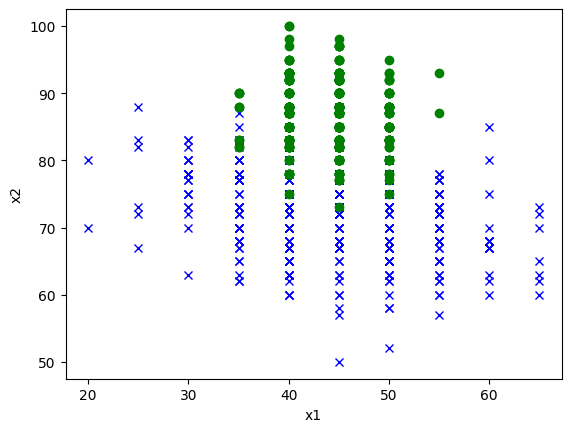

In [210]:
X, y = util.load_dataset("Data/train.csv", add_intercept=False)

util.plot(X, y, None)

# Train test spliting

In [211]:
df = np.array(pd.read_csv("Data/Naive-Bayes-Classification-Data.csv").sample(frac=1))
df.shape
df.shape
df 
df_train = df[1:750]
df_test = df[751:995]
df_train = pd.DataFrame(df_train)
df_train.to_csv("Data/train.csv", index = False, header = ['x_1', 'x_2', 'y'])
df_test = pd.DataFrame(df_test)
df_test.to_csv("Data/test.csv", index = False, header = ['x_1', 'x_2', 'y'])

# Naive Bayes class

In [212]:
class NaiveBayes():
          
    def fit(self, matrix, labels):
        n, V = matrix.shape

        matrix_y1 = matrix[labels == 1, :].sum(axis=0)
        matrix_y0 = matrix[labels == 0, :].sum(axis=0)

        # Apply Laplace smoothing 
        phi_k_y1 = (matrix_y1 + 1) / (matrix_y1.sum() + V) 
        phi_k_y0 = (matrix_y0 + 1) / (matrix_y0.sum() + V) 

        # Prior probability of class 1
        phi_y = np.mean(labels)

        return (phi_k_y1, phi_k_y0, phi_y)
        
    def predict(self, model, matrix):
        phi_k_y1, phi_k_y0, phi_y = model
        
        # p_x_y1 = (phi_k_y1 ** matrix).prod(axis=1) * phi_y
        # p_x_y0 = (phi_k_y0 ** matrix).prod(axis=1) * (1 - phi_y)

        # predict = p_x_y1 / (p_x_y1 + p_x_y0)
        # return (predict > 0.5).astype(np.int)        
        sum_log_p_x_y1 = (np.log(phi_k_y1) * matrix).sum(axis=1) + np.log(phi_y)
        sum_log_p_x_y0 = (np.log(phi_k_y0) * matrix).sum(axis=1) + np.log(1 - phi_y)

        # Return predictions as 0 or 1 integers
        return (sum_log_p_x_y1 > sum_log_p_x_y0).astype(int)

Trained Parameters: (array([0.38449533, 0.61550467]), array([0.33770216, 0.66229784]), np.float64(0.49132176234979974))


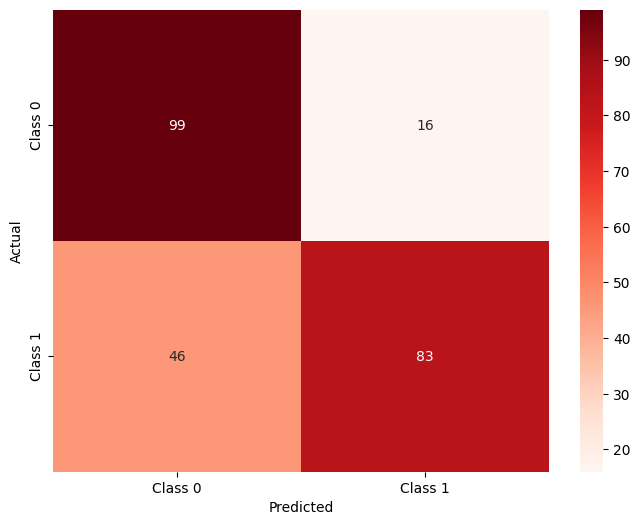

In [214]:
def run(train_path, pred_path, eval_path):
    X_train, y_train = util.load_dataset(train_path, add_intercept=False)
    X_test, y_test = util.load_dataset(pred_path, add_intercept=False)

    y_test = y_test.astype(int)
    y_train = y_train.astype(int) 

    matrix_train = X_train
    
    model = NaiveBayes()

    parameters = model.fit(matrix_train, y_train)

    print("Trained Parameters:", parameters)

    y_pred = model.predict(parameters, X_test).astype(int)

    num_classes = len(np.unique(y_test)) 

    util.confusion_matrix(y_pred, y_test, num_classes, eval_path)


if __name__ == "__main__":
    run(train_path = "Data/train.csv",
        pred_path = "Data/test.csv",
        eval_path = "Output/confusion_matrix.png")

In [193]:
import numpy as np

# Use an outer set of brackets to create a 2D array
a = np.array([[1, 2],
              [1, 2],
              [3, 4]])

# Standard way to define the mask array
b = np.array([0, 1, 1])

# This now works because 'a' is (3, 2) and 'b' is (3,)
c = a[b == 1, :]

print(c)

[[1 2]
 [3 4]]
